# Computer Vision (Image operators and filters)

By the end of this lab, you will get hands on experience working with:

*   Image Handling
*   Image Manipulation
*   Histogram and Histogram Equalization
*   Basic filtering techniques

<!-- ### **Remember this is a graded exercise.** -->

**Reminder**:

*   For every plot, make sure you provide appropriate titles, axis labels, legends, wherever applicable.
*   Add sufficient comments and explanations wherever necessary.

---


In [3]:
# Loading necessary libraries (Feel free to add new libraries if you need for any computation)

import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure, filters, io, morphology 

# Channels and color spaces

### **Exercise: Image Creation and Color Manipulation**

*   Create a 100 x 100 image for each of the below visualization

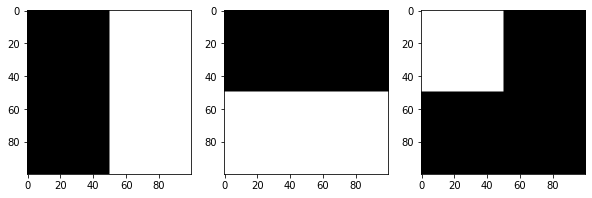

*   Visualize the created images in a 1 x 3 subplot using matplotlib.


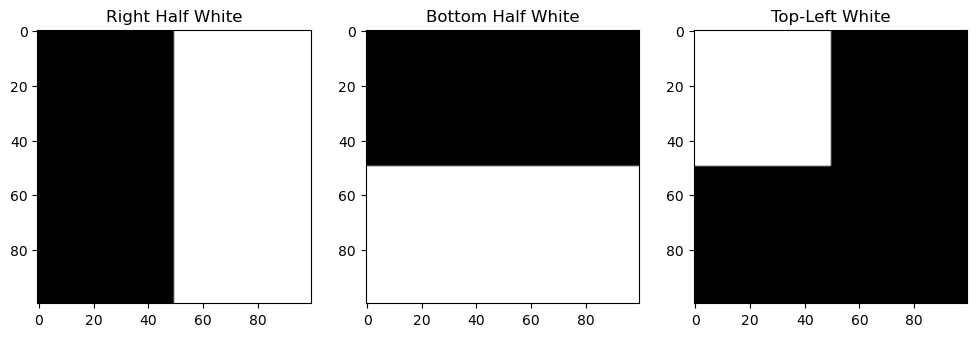

In [4]:
# Create three base black images (100x100)
img1 = np.zeros((100, 100), dtype='uint8')
img2 = np.zeros((100, 100), dtype='uint8')
img3 = np.zeros((100, 100), dtype='uint8')

# Left image: Right half is white
img1[:, 50:] = 255 

# Middle image: Bottom half is white
img2[50:, :] = 255 

# Right image: Top-left quadrant is white
img3[:50, :50] = 255 

# Visualize in 1x3 subplot
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img1, cmap='gray'); ax[0].set_title("Right Half White")
ax[1].imshow(img2, cmap='gray'); ax[1].set_title("Bottom Half White")
ax[2].imshow(img3, cmap='gray'); ax[2].set_title("Top-Left White")
plt.show()

*   Use the above three images to create the following image

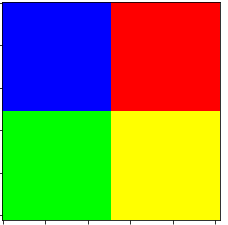
*Hint: Remember channels and color spaces*

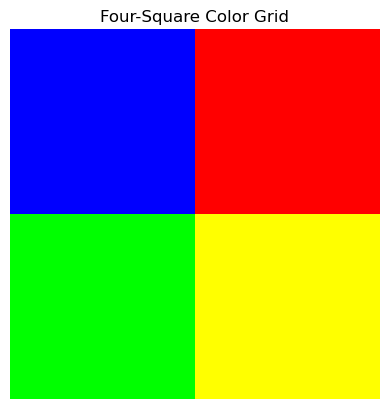

In [5]:
# Create the 3D RGB image by assigning each grayscale pattern to a channel
# Red channel (R) = Right half white (img1)
# Green channel (G) = Bottom half white (img2)
# Blue channel (B) = Top-left quadrant white (img3)

final_grid = np.stack((img1, img2, img3), axis=-1)

# Visualize the result
plt.imshow(final_grid)
plt.title("Four-Square Color Grid")
plt.axis('off') # Optional: hides the 0-100 axis markers
plt.show()

### **Exercise: Color Manipulation**

*   Read the image 'sillas.jpg' from the images folder

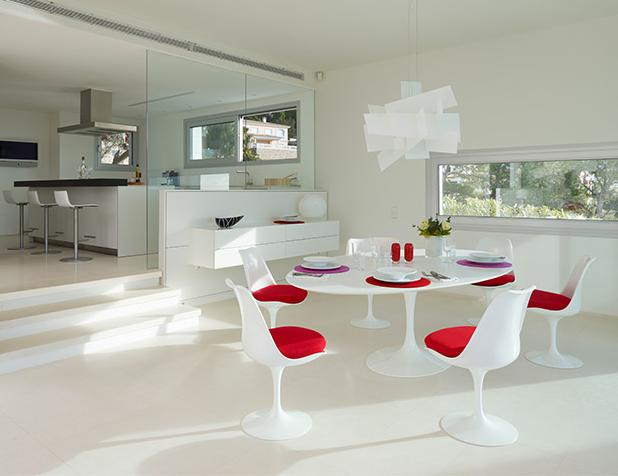

*   Extract individual channels and plot them using matplotlib subplot.



In [6]:
# Load image
img_sillas = io.imread('images/sillas.jpg')

red = img_sillas[:,:,0]
green = img_sillas[:,:,1]
blue = img_sillas[:,:,2]



*   The color **red** looks too bright for the eyes. Isn't it?? Lets change the color and see how it appears.
    *    Create a new image where everything that is **'red' is changed to 'blue'**.
*   Visualize the original image and the created image using matplotlib subplot.

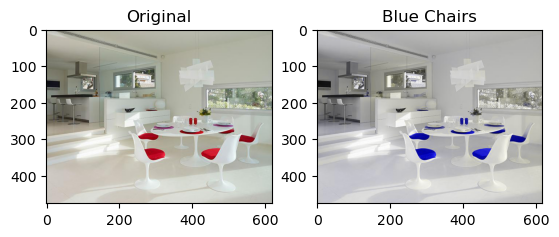

In [7]:
blue_chairs = img_sillas.copy()
blue_chairs[:,:,0] = green # Dim the red channel by replacing with green
blue_chairs[:,:,2] = red   # Move the original red intensity to blue channel

plt.subplot(1,2,1); plt.imshow(img_sillas); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(blue_chairs); plt.title("Blue Chairs")
plt.show()

# Image Manipulation

### **Exercise: Image Operators**

*   You can find images 'model.png' and 'coat.png' in the images folder (First two images of the below visualization). Your task is to create an image from the given two images such a way that the model is wearing the coat (Third image in the visualization).
*   You can also find different textures in the images folder. Your task is to change the coat texture to any one of the given textures.
*   Visualize the images similar to the given visualization.

*Hint: Think masks!!!*

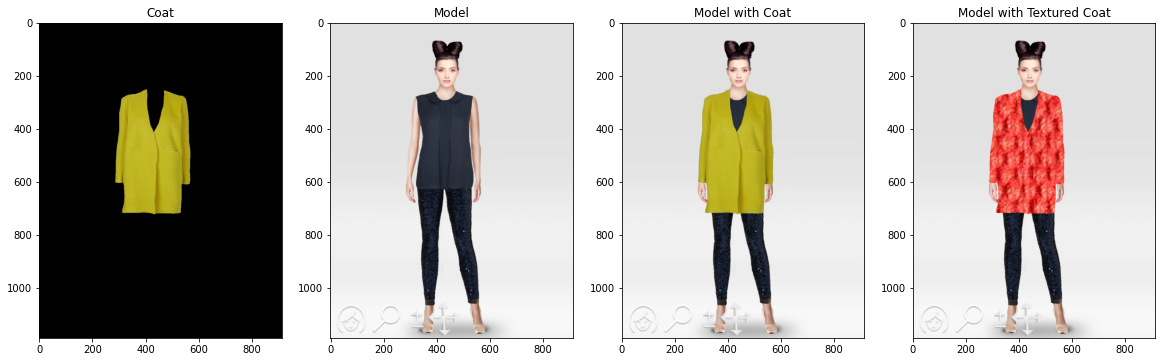

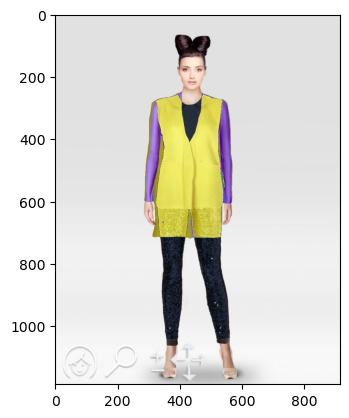

In [8]:
# Load images
model = io.imread('images/model.png')[:,:,:3]
coat = io.imread('images/coat.png')[:,:,:3]

mask = (coat[:,:,0] < 250).astype(float) 
mask_3d = np.stack([mask]*3, axis=-1)


final_img = (model * (1 - mask_3d)) + (coat * mask_3d)
final_img = model + (coat * mask_3d)

plt.imshow(final_img.astype('uint8'))
plt.show()

# Contrast Enhancement

### **Exercise: Histogram Computation**

*   Read the **'astronaut' image** from data module.
*   Convert the image to grayscale.
*   Compute the **histogram of the image.** *Hint: histogram function is available in skimage.exposure package*
*   Plot the histogram using matplotlib plot.




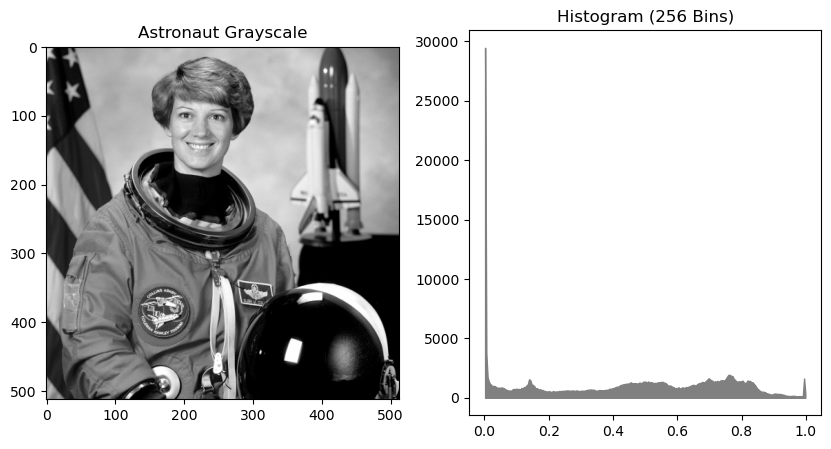

In [9]:
from skimage import data, color, exposure

# 1. Load the astronaut image directly from skimage.data
astro = data.astronaut()

# 2. Convert to grayscale (as required by the lab)
astro_gray = color.rgb2gray(astro)

# 3. Compute histogram with default bins (256)
hist, bin_centers = exposure.histogram(astro_gray)

# 4. Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(astro_gray, cmap='gray')
plt.title("Astronaut Grayscale")

plt.subplot(1, 2, 2)
plt.fill_between(bin_centers, hist, color='gray')
plt.title("Histogram (256 Bins)")
plt.show()

*   Change the bin count to 8 and compute the histogram of the image and plot the computed histogram using matplotlib plot.

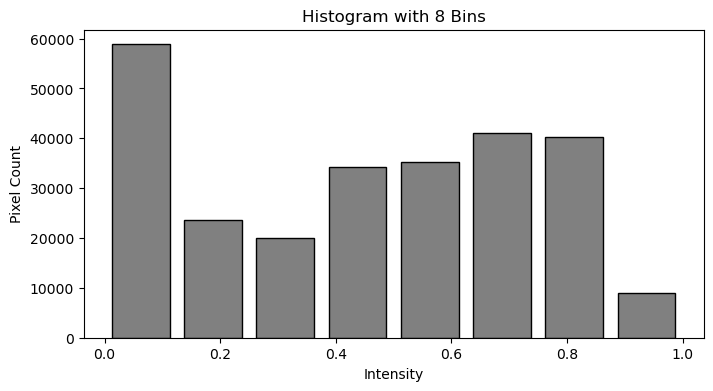

In [11]:
# Compute histogram with only 8 bins
hist_8, bin_centers_8 = exposure.histogram(astro_gray, nbins=8)

plt.figure(figsize=(8, 4))
plt.bar(bin_centers_8, hist_8, width=0.1, color='gray', edgecolor='black')
plt.title("Histogram with 8 Bins")
plt.xlabel("Intensity")
plt.ylabel("Pixel Count")
plt.show()



*   What happens when you change the bin count? Does your inference change based on the bin count? If yes, then how do you define the correct bin count.
*   What happens when the bin count is very low and what happens when it is very high?



Inference: The 8-bin histogram shows that the image is heavily biased toward low-intensity values.

Low Bin Count Impact: Because the bin count is low, we lose the ability to distinguish between the "deep black" of the arch shadows and the "dark gray" of the stone textures—they all get lumped into the first two bins.

Correct Bin Count: You should still state that 256 is the correct count for an 8-bit image to ensure no data is "lumped" together incorrectly.